<a href="https://colab.research.google.com/github/NidalNaaz/AI-Projects/blob/main/StudentFeedback/StudentFeedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries (run this once)
!pip install nltk wordcloud matplotlib scikit-learn pandas numpy -q

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Sample student reviews dataset
data = {
    'course': [
        # Machine Learning
        'Machine Learning', 'Machine Learning', 'Machine Learning', 'Machine Learning', 'Machine Learning',
        'Machine Learning', 'Machine Learning', 'Machine Learning',
        # Data Structures
        'Data Structures', 'Data Structures', 'Data Structures', 'Data Structures', 'Data Structures',
        'Data Structures', 'Data Structures', 'Data Structures',
        # Web Development
        'Web Development', 'Web Development', 'Web Development', 'Web Development', 'Web Development',
        'Web Development', 'Web Development', 'Web Development',
        # Database Systems
        'Database Systems', 'Database Systems', 'Database Systems', 'Database Systems', 'Database Systems',
        'Database Systems', 'Database Systems'
    ],
    'review': [
        # Machine Learning reviews
        'The machine learning course was fantastic. The professor explained concepts very clearly and the assignments were challenging but fair.',
        'I struggled with the math prerequisites. More background material on linear algebra would have been helpful before diving into neural networks.',
        'Excellent course content! The hands-on projects using Python were very practical and helped solidify my understanding.',
        'The workload was extremely heavy. Too many assignments in a short time, making it hard to understand the material properly.',
        'Great course overall. The professor is knowledgeable and passionate. Would love more real-world case studies though.',
        'Very poorly organized. Lecture slides were confusing and the grading rubric was unclear for most assignments.',
        'The deep learning module was incredible. Best part of the course by far. More content on this topic would be amazing.',
        'Exams were too difficult compared to what was taught in class. The difficulty gap was frustrating and discouraging.',
        # Data Structures reviews
        'Loved this course. Trees, graphs, and sorting algorithms were explained in a very intuitive way by the professor.',
        'The lab sessions were too short. We did not have enough time to implement the data structures properly during class.',
        'Fantastic teaching! The visualizations used in class made it very easy to understand complex pointer operations.',
        'Too much theory and not enough coding practice. I expected more programming exercises and hands-on implementation.',
        'The professor was very approachable and always willing to help during office hours. Really appreciated that support.',
        'Assignments were repetitive and boring after the third week. Needed more variety and creative problem-solving tasks.',
        'Clear explanations and good pace. The course was well-structured from basic arrays to advanced graph algorithms.',
        'The exam was unfair and covered topics that were never properly discussed in class. Very disappointed with the assessment.',
        # Web Development reviews
        'Amazing course! Learned React, Node.js, and MongoDB. The final project was incredibly fun and professionally rewarding.',
        'The CSS section was too rushed. We spent only one week on styling but it is such an important skill for web work.',
        'Loved every session. The professor brought real industry experience and shared very practical tips we could use right away.',
        'The backend section was confusing without proper API documentation or examples. More detailed guidance was needed there.',
        'Best course of the semester without a doubt. Very relevant, modern technologies and excellent teaching from day one.',
        'Group projects were poorly managed. No clear guidelines on collaboration and roles caused a lot of team confusion.',
        'The course introduced us to the full stack in a short time which was impressive. Would appreciate a part two.',
        'Deployment and hosting topics were completely skipped. This is a critical real-world skill that should be covered.',
        # Database Systems reviews
        'SQL and normalization topics were well explained. The professor used great real world examples from industry projects.',
        'The NoSQL section felt rushed and incomplete. We barely touched MongoDB before moving to the next topic.',
        'Excellent professor who made complex transaction concepts easy to understand through visual walkthroughs in class.',
        'Too much memorization required. The course focused heavily on syntax rather than on database design principles.',
        'Very practical course with good industry relevance. Learned skills I will definitely use in my future career.',
        'The query optimization topic was skipped entirely. This is essential knowledge for any serious database developer.',
        'The labs were well designed and gave us enough time to practice writing complex queries and stored procedures.'
    ]
}

df = pd.DataFrame(data)
print(f"Dataset loaded: {len(df)} reviews across {df['course'].nunique()} courses")
print("\nSample reviews:")
df.head(4)

Dataset loaded: 31 reviews across 4 courses

Sample reviews:


,course,review
0,Machine Learning,The machine learning course was fantastic. The...
1,Machine Learning,I struggled with the math prerequisites. More ...
2,Machine Learning,Excellent course content! The hands-on project...
3,Machine Learning,The workload was extremely heavy. Too many ass...


In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text preprocessing pipeline.
    Returns a cleaned string ready for feature extraction.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 5. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Show before/after
print("BEFORE preprocessing:")
print(df['review'][0])
print("\nAFTER preprocessing:")
print(df['cleaned_review'][0])

BEFORE preprocessing:
The machine learning course was fantastic. The professor explained concepts very clearly and the assignments were challenging but fair.

AFTER preprocessing:
machine learning course fantastic professor explained concept clearly assignment challenging fair


In [5]:
# Build TF-IDF feature matrix
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,      # Keep top 100 most meaningful words
    min_df=2,              # Word must appear in at least 2 reviews
    max_df=0.85,           # Ignore words in more than 85% of reviews (too common)
    ngram_range=(1, 2)     # Include single words AND two-word phrases
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_review'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} reviews × {tfidf_matrix.shape[1]} features")
print(f"\nTop 20 TF-IDF features (vocabulary):")
print(list(feature_names[:20]))

TF-IDF Matrix shape: (31, 64)
  → 31 reviews × 64 features

Top 20 TF-IDF features (vocabulary):
['algorithm', 'amazing', 'assignment', 'best', 'class', 'clear', 'complex', 'concept', 'confusing', 'content', 'course', 'covered', 'database', 'easy', 'easy understand', 'enough', 'enough time', 'exam', 'example', 'excellent']


In [6]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Returns compound score and sentiment label."""
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series({'sentiment_score': compound, 'sentiment': label})

# Apply to original (not cleaned) reviews for better VADER accuracy
df[['sentiment_score', 'sentiment']] = df['review'].apply(get_sentiment)

print("Sentiment distribution across all reviews:")
print(df['sentiment'].value_counts())
print("\nSentiment per course:")
print(df.groupby(['course', 'sentiment']).size().unstack(fill_value=0))

Sentiment distribution across all reviews:
sentiment
Positive    20
Negative     7
Neutral      4
Name: count, dtype: int64

Sentiment per course:
sentiment         Negative  Neutral  Positive
course                                       
Data Structures          1        3         4
Database Systems         0        1         6
Machine Learning         3        0         5
Web Development          3        0         5


In [7]:
N_TOPICS = 5

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20
)

lda_matrix = lda_model.fit_transform(tfidf_matrix)

# Human-readable topic names (based on top words)
topic_labels = [
    'Teaching Quality',
    'Workload & Difficulty',
    'Course Content',
    'Assessments & Exams',
    'Practical Skills'
]

print("Top 8 words per topic:\n")
for i, topic in enumerate(lda_model.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-8:][::-1]]
    print(f"Topic {i+1} — {topic_labels[i]}:")
    print(f"  {', '.join(top_words)}\n")

# Assign dominant topic to each review
df['dominant_topic_id'] = lda_matrix.argmax(axis=1)
df['dominant_topic'] = df['dominant_topic_id'].map(dict(enumerate(topic_labels)))

print("Topic distribution across reviews:")
print(df['dominant_topic'].value_counts())

Top 8 words per topic:

Topic 1 — Teaching Quality:
  professor, class, concept, exam, database, much, course, mongodb

Topic 2 — Workload & Difficulty:
  assignment, poorly, week, confusing, needed, one, without, course

Topic 3 — Course Content:
  would, material, industry, topic, practice, much, handson, course

Topic 4 — Assessments & Exams:
  topic, skipped, covered, class, query, properly, session, lab

Topic 5 — Practical Skills:
  course, clear, algorithm, graph, good, short time, part, content

Topic distribution across reviews:
dominant_topic
Workload & Difficulty    9
Assessments & Exams      8
Teaching Quality         6
Course Content           5
Practical Skills         3
Name: count, dtype: int64


In [8]:
# Suggestion mapping: negative sentiment on a topic → recommendation
suggestion_map = {
    'Teaching Quality':      'Consider providing additional professor training or mentoring resources.',
    'Workload & Difficulty': 'Review the assignment schedule and reduce overlapping deadlines.',
    'Course Content':        'Update curriculum to include more real-world examples and case studies.',
    'Assessments & Exams':   'Align exam difficulty with lecture content and clarify grading rubrics.',
    'Practical Skills':      'Add more hands-on labs and project-based learning activities.'
}

# Build per-course summary
results = []
for course in df['course'].unique():
    course_df = df[df['course'] == course]
    avg_score   = course_df['sentiment_score'].mean()
    overall     = 'Positive' if avg_score > 0.05 else ('Negative' if avg_score < -0.05 else 'Neutral')
    pos = (course_df['sentiment'] == 'Positive').sum()
    neg = (course_df['sentiment'] == 'Negative').sum()
    neu = (course_df['sentiment'] == 'Neutral').sum()

    # Find negative-topic pairs
    neg_reviews   = course_df[course_df['sentiment'] == 'Negative']
    problem_topic = neg_reviews['dominant_topic'].mode()[0] if len(neg_reviews) > 0 else 'None'
    suggestion    = suggestion_map.get(problem_topic, 'No issues detected — keep up the great work!')

    results.append({
        'Course':            course,
        'Overall Sentiment': overall,
        'Avg Score':         round(avg_score, 3),
        'Positive':          pos,
        'Neutral':           neu,
        'Negative':          neg,
        'Main Issue':        problem_topic,
        'Suggestion':        suggestion
    })

summary_df = pd.DataFrame(results)
print("Course Improvement Summary:\n")
for _, row in summary_df.iterrows():
    print(f"Course: {row['Course']}")
    print(f"  Overall: {row['Overall Sentiment']} (score: {row['Avg Score']})")
    print(f"  Reviews: {row['Positive']} positive, {row['Neutral']} neutral, {row['Negative']} negative")
    print(f"  Main issue topic: {row['Main Issue']}")
    print(f"  Suggestion: {row['Suggestion']}")
    print()

Course Improvement Summary:

Course: Machine Learning
  Overall: Positive (score: 0.237)
  Reviews: 5 positive, 0 neutral, 3 negative
  Main issue topic: Workload & Difficulty
  Suggestion: Review the assignment schedule and reduce overlapping deadlines.

Course: Data Structures
  Overall: Positive (score: 0.276)
  Reviews: 4 positive, 3 neutral, 1 negative
  Main issue topic: Assessments & Exams
  Suggestion: Align exam difficulty with lecture content and clarify grading rubrics.

Course: Web Development
  Overall: Positive (score: 0.348)
  Reviews: 5 positive, 0 neutral, 3 negative
  Main issue topic: Workload & Difficulty
  Suggestion: Review the assignment schedule and reduce overlapping deadlines.

Course: Database Systems
  Overall: Positive (score: 0.451)
  Reviews: 6 positive, 1 neutral, 0 negative
  Main issue topic: None
  Suggestion: No issues detected — keep up the great work!



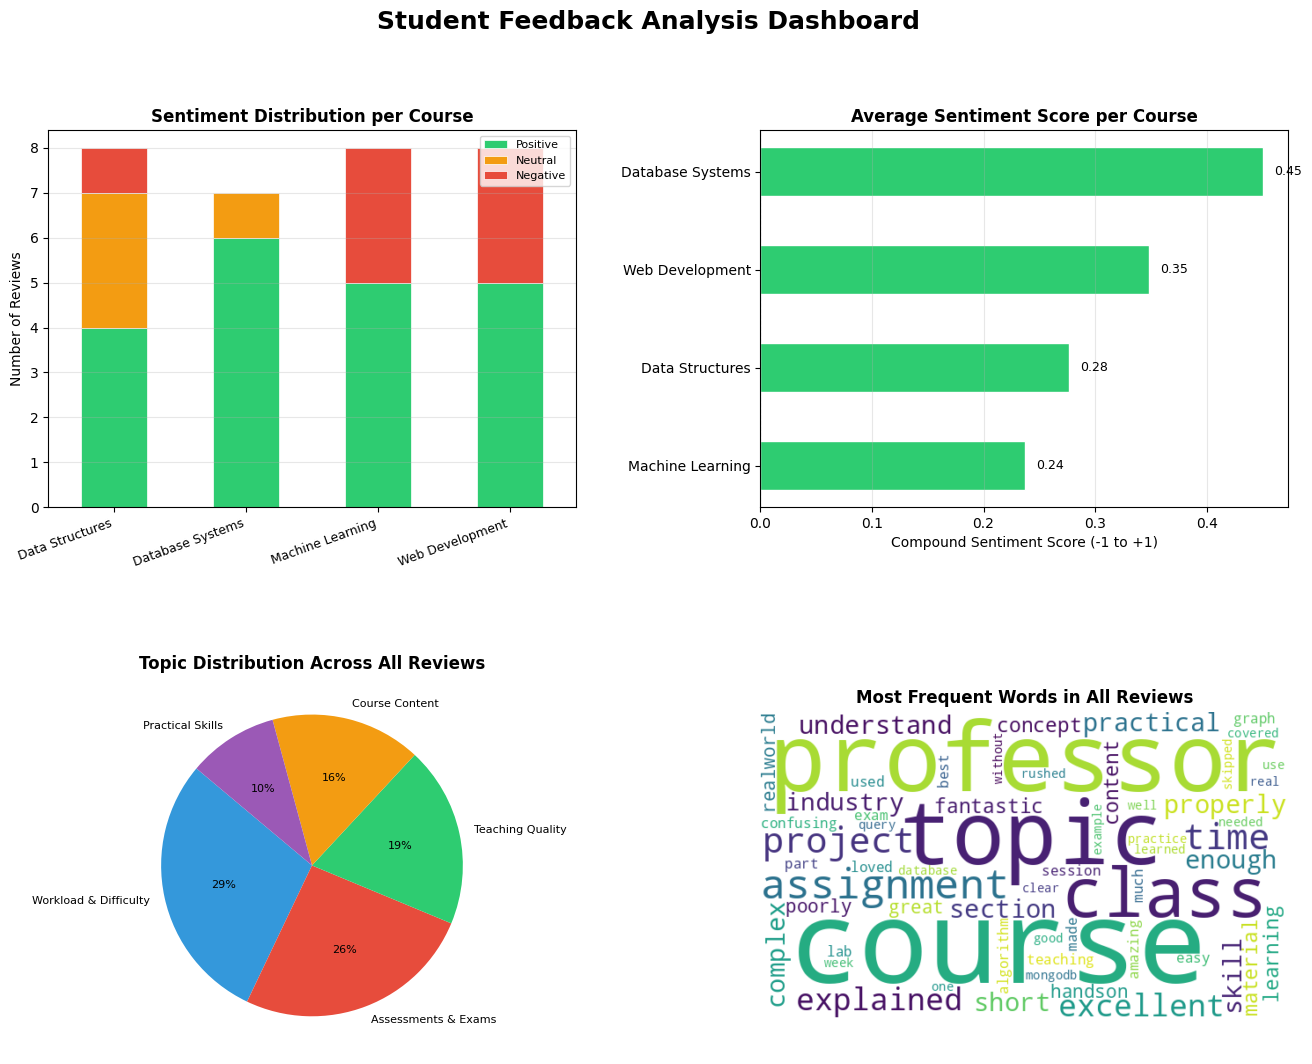

Dashboard saved as 'feedback_dashboard.png'


In [9]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Student Feedback Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

# --- Chart 1: Stacked Sentiment per Course ---
ax1 = fig.add_subplot(gs[0, 0])
sent_pivot = df.groupby(['course', 'sentiment']).size().unstack(fill_value=0)
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in sent_pivot.columns:
        sent_pivot[col] = 0
sent_pivot = sent_pivot[['Positive', 'Neutral', 'Negative']]
sent_pivot.plot(
    kind='bar', stacked=True, ax=ax1,
    color=[COLORS['Positive'], COLORS['Neutral'], COLORS['Negative']],
    edgecolor='white', linewidth=0.5
)
ax1.set_title('Sentiment Distribution per Course', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Number of Reviews')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2: Avg Sentiment Score per Course ---
ax2 = fig.add_subplot(gs[0, 1])
avg_scores = df.groupby('course')['sentiment_score'].mean().sort_values()
bar_colors = [COLORS['Positive'] if s > 0.05 else (COLORS['Negative'] if s < -0.05 else COLORS['Neutral'])
              for s in avg_scores]
bars = ax2.barh(avg_scores.index, avg_scores.values, color=bar_colors, edgecolor='white', height=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_title('Average Sentiment Score per Course', fontweight='bold')
ax2.set_xlabel('Compound Sentiment Score (-1 to +1)')
for bar, val in zip(bars, avg_scores.values):
    ax2.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# --- Chart 3: Topic Distribution Pie ---
ax3 = fig.add_subplot(gs[1, 0])
topic_counts = df['dominant_topic'].value_counts()
pie_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
wedges, texts, autotexts = ax3.pie(
    topic_counts.values,
    labels=topic_counts.index,
    autopct='%1.0f%%',
    colors=pie_colors[:len(topic_counts)],
    startangle=140,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax3.set_title('Topic Distribution Across All Reviews', fontweight='bold')

# --- Chart 4: Word Cloud ---
ax4 = fig.add_subplot(gs[1, 1])
all_text = ' '.join(df['cleaned_review'].tolist())
wc = WordCloud(
    width=600, height=350,
    background_color='white',
    colormap='viridis',
    max_words=60,
    collocations=False
).generate(all_text)
ax4.imshow(wc, interpolation='bilinear')
ax4.axis('off')
ax4.set_title('Most Frequent Words in All Reviews', fontweight='bold')

plt.savefig('feedback_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as 'feedback_dashboard.png'")

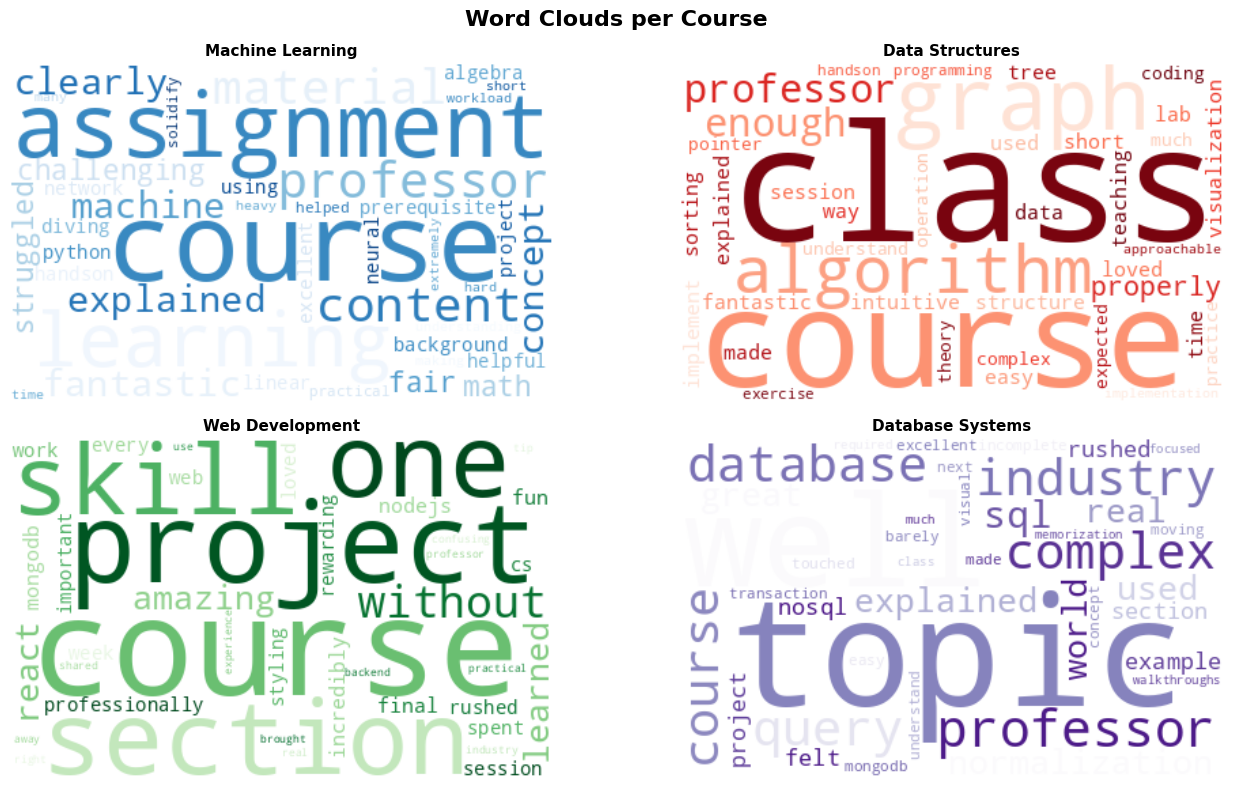

Word clouds saved as 'course_wordclouds.png'


In [10]:
courses = df['course'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Word Clouds per Course', fontsize=16, fontweight='bold')
axes = axes.flatten()

colormaps = ['Blues', 'Reds', 'Greens', 'Purples']

for i, course in enumerate(courses):
    text = ' '.join(df[df['course'] == course]['cleaned_review'].tolist())
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap=colormaps[i],
        max_words=40,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(course, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('course_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds saved as 'course_wordclouds.png'")

In [11]:
print("=" * 70)
print("       STUDENT FEEDBACK SYSTEM — COURSE IMPROVEMENT REPORT")
print("=" * 70)

for _, row in summary_df.iterrows():
    score_bar = '█' * int((row['Avg Score'] + 1) * 10)
    print(f"\n{'─' * 60}")
    print(f"  COURSE: {row['Course']}")
    print(f"  Overall Sentiment : {row['Overall Sentiment']} (avg score: {row['Avg Score']})")
    print(f"  Review Breakdown  : {row['Positive']} positive | {row['Neutral']} neutral | {row['Negative']} negative")
    print(f"  Main Issue Area   : {row['Main Issue']}")
    print(f"  Recommendation    : {row['Suggestion']}")

print(f"\n{'=' * 70}")
print("  Pipeline complete! See charts above for visualizations.")
print(f"{'=' * 70}")

       STUDENT FEEDBACK SYSTEM — COURSE IMPROVEMENT REPORT

────────────────────────────────────────────────────────────
  COURSE: Machine Learning
  Overall Sentiment : Positive (avg score: 0.237)
  Review Breakdown  : 5 positive | 0 neutral | 3 negative
  Main Issue Area   : Workload & Difficulty
  Recommendation    : Review the assignment schedule and reduce overlapping deadlines.

────────────────────────────────────────────────────────────
  COURSE: Data Structures
  Overall Sentiment : Positive (avg score: 0.276)
  Review Breakdown  : 4 positive | 3 neutral | 1 negative
  Main Issue Area   : Assessments & Exams
  Recommendation    : Align exam difficulty with lecture content and clarify grading rubrics.

────────────────────────────────────────────────────────────
  COURSE: Web Development
  Overall Sentiment : Positive (avg score: 0.348)
  Review Breakdown  : 5 positive | 0 neutral | 3 negative
  Main Issue Area   : Workload & Difficulty
  Recommendation    : Review the assignme